In [1]:
import torch

In [2]:
from DDPM import sample_v2, LinearNoiseScheduler
from DiT_v2 import DiT
from VAE import VAE

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out ht

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# vae = VAE(ch = 128, latent_channels = 4).to(device)
vae = VAE(device = device, freeze = True, scaling_factor = 0.18215).to(device)


num_timesteps = 1000
beta_start    = 0.0001
beta_end      = 0.02


scheduler = LinearNoiseScheduler(num_timesteps  = num_timesteps,
                                     beta_start = beta_start,
                                     beta_end   = beta_end)


dit = DiT(d_model          = 768,
          g_channels       = 4,
          grid_size        = 32,
          patch_size       = 4,
          timestep_emb_dim = 768,
          number_emb_dim   = 768,
          num_layers       = 12,
          num_heads        = 12)

vae.eval()
dit.eval()

# vae.load_state_dict(torch.load('vae_v2.pth', map_location = device))
dit.load_state_dict(torch.load('DiT_w_num.pth', map_location = device))

<All keys matched successfully>

In [7]:
import torch
from tqdm import tqdm
from torchvision.utils import make_grid
import torchvision

@torch.no_grad()
def sample_v2(latent_grid_size: int, dit, vae, device, scheduler, number):
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, torch.as_tensor(i).unsqueeze(0).to(device), torch.as_tensor(number).unsqueeze(0).to(device))

        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

    img_tensor = vae.decode(xt)
    img_tensor = torch.clamp(img_tensor, -1., 1.).detach().cpu()
    img_tensor = (img_tensor + 1) / 2
    grid = make_grid(img_tensor, nrow=2)
    img = torchvision.transforms.ToPILImage()(grid)
    return img

In [11]:
2**31 - 1

2147483647

1000it [00:55, 18.01it/s]


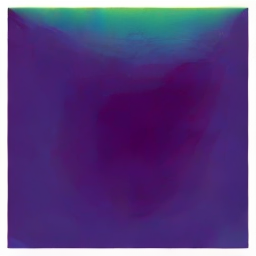

In [8]:
n = 10
img = sample_v2(32, dit, vae, device, scheduler, n)
img

1000it [00:53, 18.58it/s]


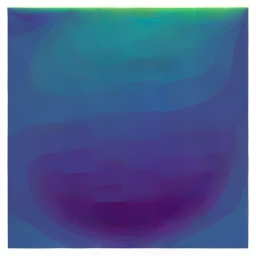

In [9]:
n = 2000
img = sample_v2(32, dit, vae, device, scheduler, n)
img

1000it [01:08, 14.58it/s]


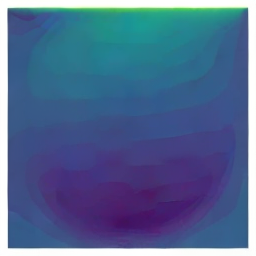

In [12]:
n = 3000
img = sample_v2(32, dit, vae, device, scheduler, n)
img

In [4]:
import torch
from tqdm import tqdm
from torchvision.utils import make_grid
import torchvision


@torch.no_grad()
def sample_v2(latent_grid_size: int, dit, vae, device, scheduler):
    imgs = []
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, torch.as_tensor(i).unsqueeze(0).to(device))
        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))


        if i % 10 == 0:
            img_tensor = vae.decode(xt)
            img_tensor = torch.clamp(img_tensor, -1., 1.).detach().cpu()
            img_tensor = (img_tensor + 1) / 2
            grid = make_grid(img_tensor, nrow=2)
            img = torchvision.transforms.ToPILImage()(grid)
            imgs.append(img)

    img_tensor = vae.decode(xt)
    img_tensor = torch.clamp(img_tensor, -1., 1.).detach().cpu()
    img_tensor = (img_tensor + 1) / 2
    grid = make_grid(img_tensor, nrow=2)
    img = torchvision.transforms.ToPILImage()(grid)
    imgs.append(img)
    return imgs

In [5]:
imgs = sample_v2(32, dit, vae, device, scheduler)

0it [00:00, ?it/s]

1000it [04:28,  3.72it/s]


In [6]:
import imageio.v2 as imageio
import numpy as np

# imgs: List[PIL.Image.Image]
fps = 10

with imageio.get_writer("lid_sample.mp4", fps=fps, codec="libx264") as writer:
    for img in imgs:
        writer.append_data(np.array(img.convert("RGB")))

In [4]:
imgs = [sample_v2(32, dit, vae, device, scheduler) for i in range(9)]

1000it [00:44, 22.40it/s]
1000it [00:44, 22.72it/s]
1000it [00:43, 22.73it/s]
1000it [00:43, 23.00it/s]
1000it [00:43, 22.76it/s]
1000it [00:44, 22.62it/s]
1000it [00:43, 22.85it/s]
1000it [00:44, 22.35it/s]
1000it [00:45, 22.22it/s]


In [5]:
from PIL import Image

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows*cols

    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    grid_w, grid_h = grid.size
    
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid


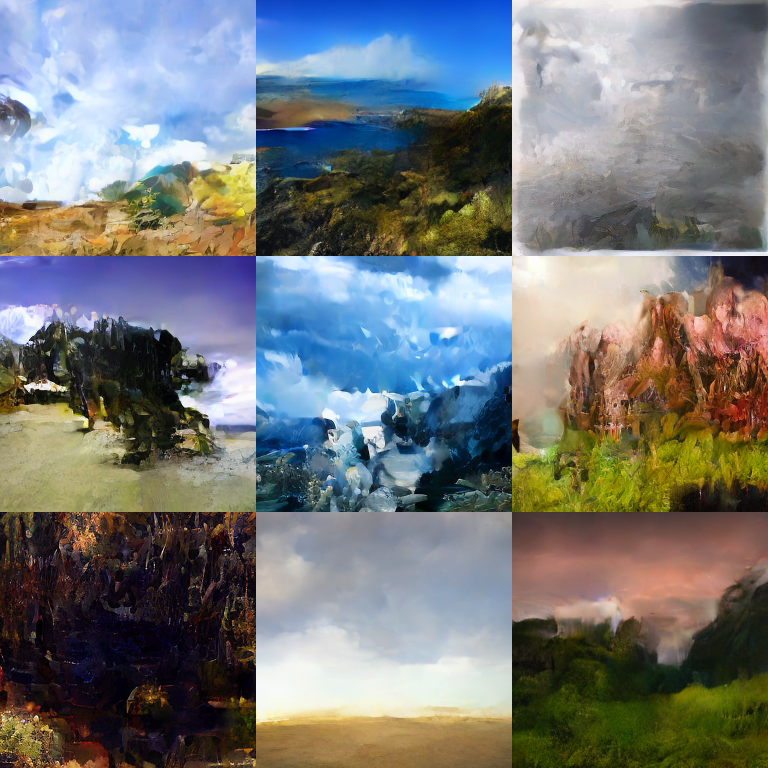

In [6]:
image_grid(imgs, 3, 3)

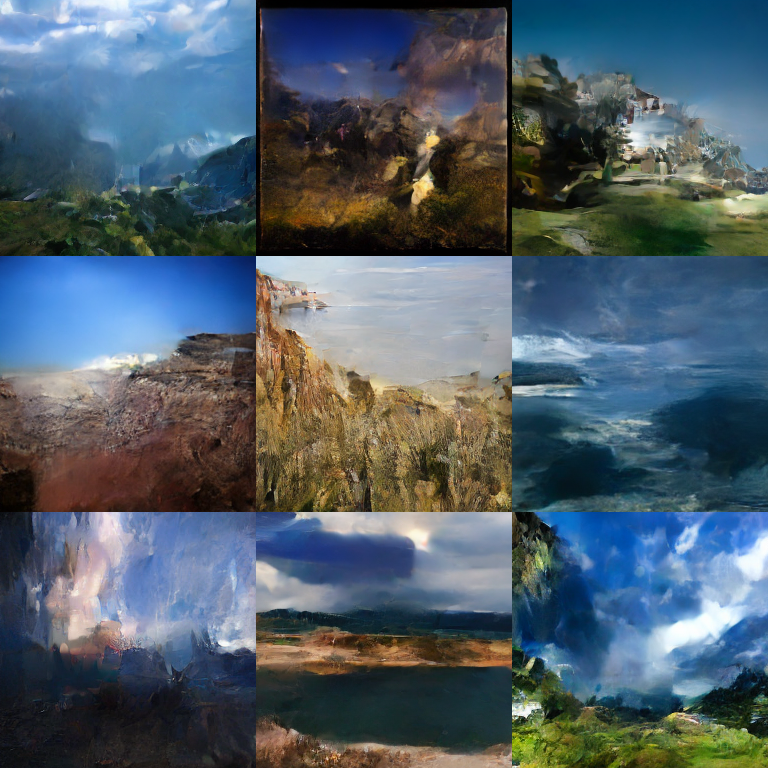

In [8]:
image_grid(imgs, 3, 3)

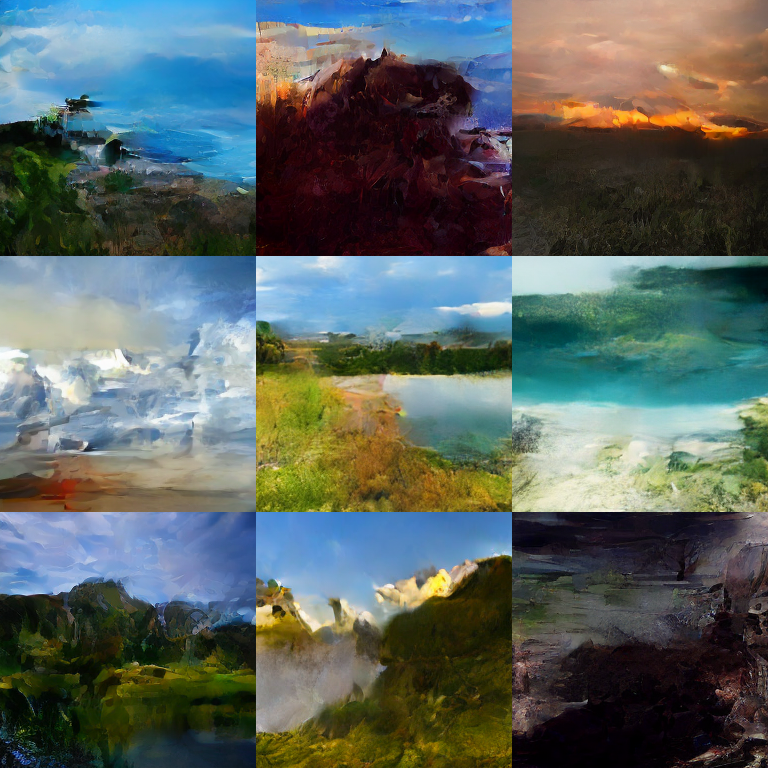

In [6]:
image_grid(imgs, 3, 3)

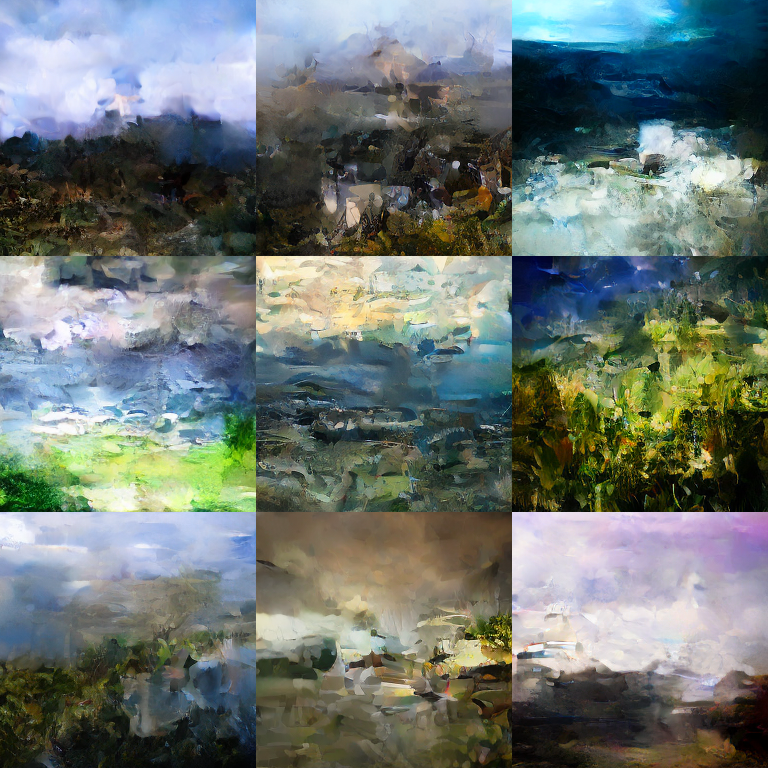

In [ ]:
image_grid(imgs, 3, 3)

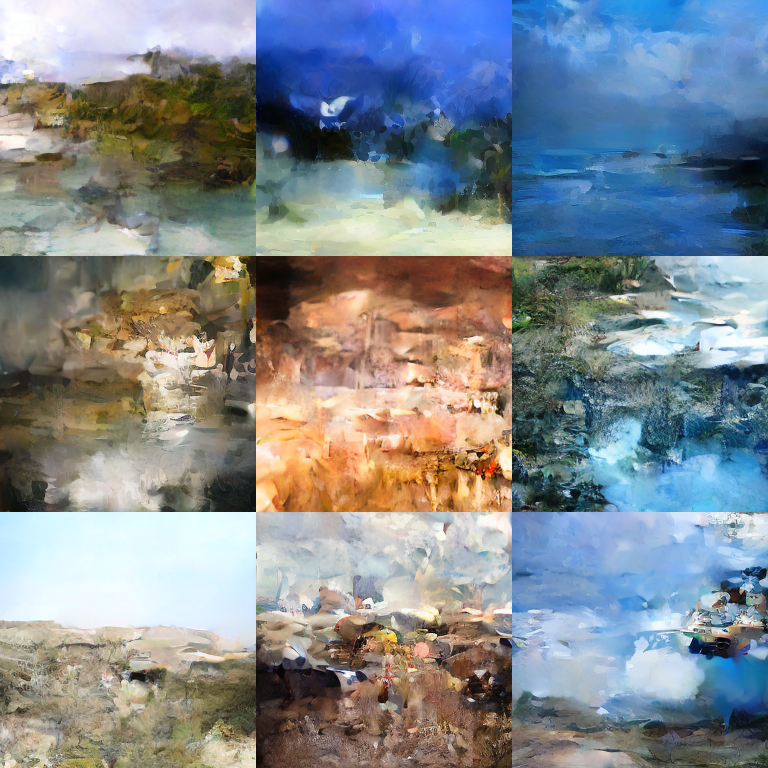

In [26]:
image_grid(imgs, 3, 3)

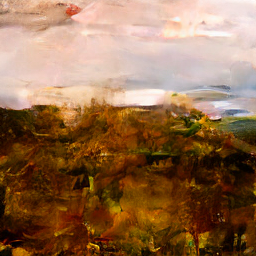

In [16]:
img

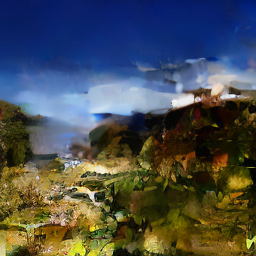

In [14]:
img

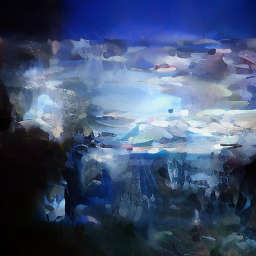

In [8]:
img

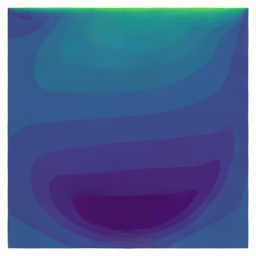

In [30]:
img

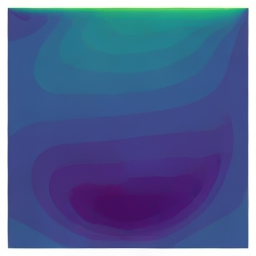

In [32]:
img

In [4]:
import torch

a = torch.tensor([0])
torch.cat((a, torch.arange(0,16,1)), 0).shape

torch.Size([17])